# Compact / Two-Dimensional TV Variational Mode Decomposition (CVMD2D)

This notebook reproduces the theory and MATLAB demos of

> Zosso D., Dragomiretskiy K., Bertozzi A.L., Weiss P.S.  
> *Two-Dimensional Compact Variational Mode Decomposition.*  
> Journal of Mathematical Imaging and Vision, 58(2):294–320, 2017.  
> https://doi.org/10.1007/s10851-017-0710-z

MATLAB reference: `VMD_2D_TV.m` / `VMD_2D_TV_test.m`  
(File Exchange: *Two-Dimensional Compact Variational Mode Decomposition*).

**Idea.** Classical 2D-VMD recovers **spectrally narrow** modes, but sharp spatial
onsets violate the Bedrosian / narrow-band assumption. CVMD2D (2D-TV-VMD) introduces
**binary spatial supports** $A_k$ that mask each narrow-band carrier $u_k$, so spatial
and spectral support are decoupled. Total-variation / MBO dynamics make the supports
compact; constraining them to a partition yields **spectrum-based segmentation**.


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift

from pysdkit import CVMD2D
from pysdkit.data import test_grayscale

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
print(CVMD2D())


Compact Variational Mode Decomposition for 2D Images (CVMD2D)


## 2. Model and principles (from the paper)

### 2.1 Classical 2D-VMD

An image $f:\mathbb{R}^2\to\mathbb{R}$ is written as a sum of $K$ modes $u_k$ with
centre frequencies $\boldsymbol{\omega}_k$. Each mode is converted to a **directional
analytic signal** $u_k^{\mathrm{AS}}$ (half-plane Hilbert transform aligned with
$\boldsymbol{\omega}_k$), demodulated to baseband, and penalised for spectral spread
(Dirichlet energy):

$$
\min_{\{u_k\},\{\boldsymbol{\omega}_k\}}
\sum_{k=1}^{K}
\alpha_k\,\bigl\|
\nabla\bigl(u_k^{\mathrm{AS}}(\mathbf{x})\,e^{-j\langle\boldsymbol{\omega}_k,\mathbf{x}\rangle}\bigr)
\bigr\|_2^2
\quad\text{s.t.}\quad
\sum_{k=1}^{K}u_k(\mathbf{x})=f(\mathbf{x}).
$$

The equality constraint is handled by an **augmented Lagrangian** (quadratic penalty
+ multiplier $\lambda$), solved by ADMM-style alternate updates of $u_k$,
$\boldsymbol{\omega}_k$ and $\lambda$:

$$
\mathcal{L}(\{u_k\},\{\boldsymbol{\omega}_k\},\lambda)
=
\sum_k\alpha_k\bigl\|
\nabla\bigl(u_k^{\mathrm{AS}} e^{-j\langle\boldsymbol{\omega}_k,\mathbf{x}\rangle}\bigr)
\bigr\|_2^2
+\Bigl\|f-\sum_k u_k+\tfrac{\lambda}{2}\Bigr\|_2^2
-\Bigl\|\tfrac{\lambda}{2}\Bigr\|_2^2.
$$

In Fourier space the $u$-update is a **Wiener filter** around $\boldsymbol{\omega}_k$;
the $\boldsymbol{\omega}$-update is the power-spectrum barycentre.

### 2.2 Compact supports $A_k$ (2D-TV-VMD)

To allow **sharp spatial cut-offs** while keeping carriers narrow-band, binary masks
$A_k:\Omega\to\{0,1\}$ are introduced. Reconstruction uses the masked carriers:

$$
f(\mathbf{x})\approx\sum_{k=1}^{K} A_k(\mathbf{x})\,v_k(\mathbf{x}),
$$

where $v_k$ is a spatial-domain splitting variable coupled to $u_k$
(weight $\rho_k$). Supports are regularised by an **$L^1$ area** term ($\beta$) and a
**TV / mean-curvature** term implemented by Merriman–Bence–Osher (MBO) threshold
dynamics (heat diffusion weight $\gamma$, step $t$):

$$
A_k\;\leftarrow\;
\mathbf{1}_{\{\cdot\,\ge\,1/2\}}
\Bigl(
\mathcal{H}_{\gamma t}\bigl[A_k + t\,(\text{fidelity soft-update})\bigr]
\Bigr),
$$

with $\mathcal{H}_{\gamma t}$ the heat kernel in Fourier space
$(1+t\gamma\|\boldsymbol{\xi}\|^2)^{-1}$.

### 2.3 Three scheduled phases (`A_phase = [a, b]`)

| Iterations | Name | Behaviour |
|---|---|---|
| $1\ldots a-1$ | **2D-VMD** | $A_k\equiv 1$; classical spectral splitting |
| $a\ldots b-1$ | **2D-TV-VMD** | individual MBO updates of each $A_k$ (supports may overlap) |
| $b\ldots N$ | **2D-TV-VMD-Seg** | joint MBO + **winner-takes-all** → $\sum_k A_k(\mathbf{x})=1$ |

Optional **artifact map** $X$: pixels with residual energy $\ge\delta$ are excluded
from the fidelity term (set $\delta=\infty$ to disable).

### 2.4 Submodes $M$

Several spectral submodes $m=1\ldots M$ can share one spatial support $A_k$
(crystal grains, multi-orientation textures):

$$
A_k(\mathbf{x})\sum_{m=1}^{M} v_{k,m}(\mathbf{x}).
$$


## 3. Helper visualisation


In [2]:
def show_modes(signal, u, A=None, omega=None, title="CVMD2D"):
    """Plot input, modes u_k (and A_k u_k), spectra, and centre frequencies."""
    K = u.shape[2]
    M = u.shape[3]
    ncols = K + 1
    fig, axes = plt.subplots(2, ncols, figsize=(2.4 * ncols, 5.0))
    if ncols == 1:
        axes = np.asarray(axes).reshape(2, 1)

    axes[0, 0].imshow(signal, cmap="gray")
    axes[0, 0].set_title("input $f$")
    axes[0, 0].axis("off")
    axes[1, 0].imshow(np.log1p(np.abs(fftshift(fft2(signal)))), cmap="magma")
    axes[1, 0].set_title("$|\\hat f|$")
    axes[1, 0].axis("off")

    for k in range(K):
        uk = np.sum(u[:, :, k, :], axis=2)
        show = A[:, :, k] * uk if A is not None else uk
        axes[0, k + 1].imshow(show, cmap="gray")
        axes[0, k + 1].set_title(
            f"$A_{{{k+1}}} u_{{{k+1}}}$" if A is not None else f"$u_{{{k+1}}}$"
        )
        axes[0, k + 1].axis("off")

        spec = np.log1p(np.abs(fftshift(fft2(uk))))
        axes[1, k + 1].imshow(spec, cmap="magma")
        axes[1, k + 1].set_title(f"$|\\hat u_{{{k+1}}}|$")
        axes[1, k + 1].axis("off")

        if omega is not None:
            # omega is (2, K, M) in normalised frequency; map to image coords for overlay
            hy, hx = signal.shape
            for m in range(M):
                ox = (omega[0, k, m] + 0.5) * hx
                oy = (omega[1, k, m] + 0.5) * hy
                axes[1, k + 1].plot(ox, oy, "c+", ms=10, mew=1.5)

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def show_supports(A, title="supports $A_k$"):
    K = A.shape[2]
    fig, axes = plt.subplots(1, K, figsize=(2.4 * K, 2.6))
    if K == 1:
        axes = [axes]
    for k in range(K):
        axes[k].imshow(A[:, :, k], cmap="gray", vmin=0, vmax=1)
        axes[k].set_title(f"$A_{{{k+1}}}$")
        axes[k].axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

## 4. MATLAB case 1 — Jerome’s texture (`examples/texture.mat`)

Parameters copied from `VMD_2D_TV_test.m` **case 1**.  
The official MATLAB `texture.mat` is stored in this folder as `examples/texture.mat`
(field `f`). PySDKit’s `test_grayscale()` is the same texture and is used as a fallback.

For a quick interactive run we use a mild spatial downsample and a shorter
`max_iter`; set `FAST = False` to match the MATLAB schedule more closely
(`N=130`, `A_phase=[100, Inf]` on the full $256\times256$ image).


loaded C:\Users\whenx\Desktop\PySDKit\examples\texture.mat
u shape: (128, 128, 5, 1)   omega (2,K,M): (2, 5, 1)
centre frequencies ω (fx, fy) per mode:
 [[ 0.          0.        ]
 [ 0.49070023  0.29899917]
 [-0.14738694  0.36768738]
 [-0.14728762  0.36779341]
 [ 0.36601044  0.07307649]]


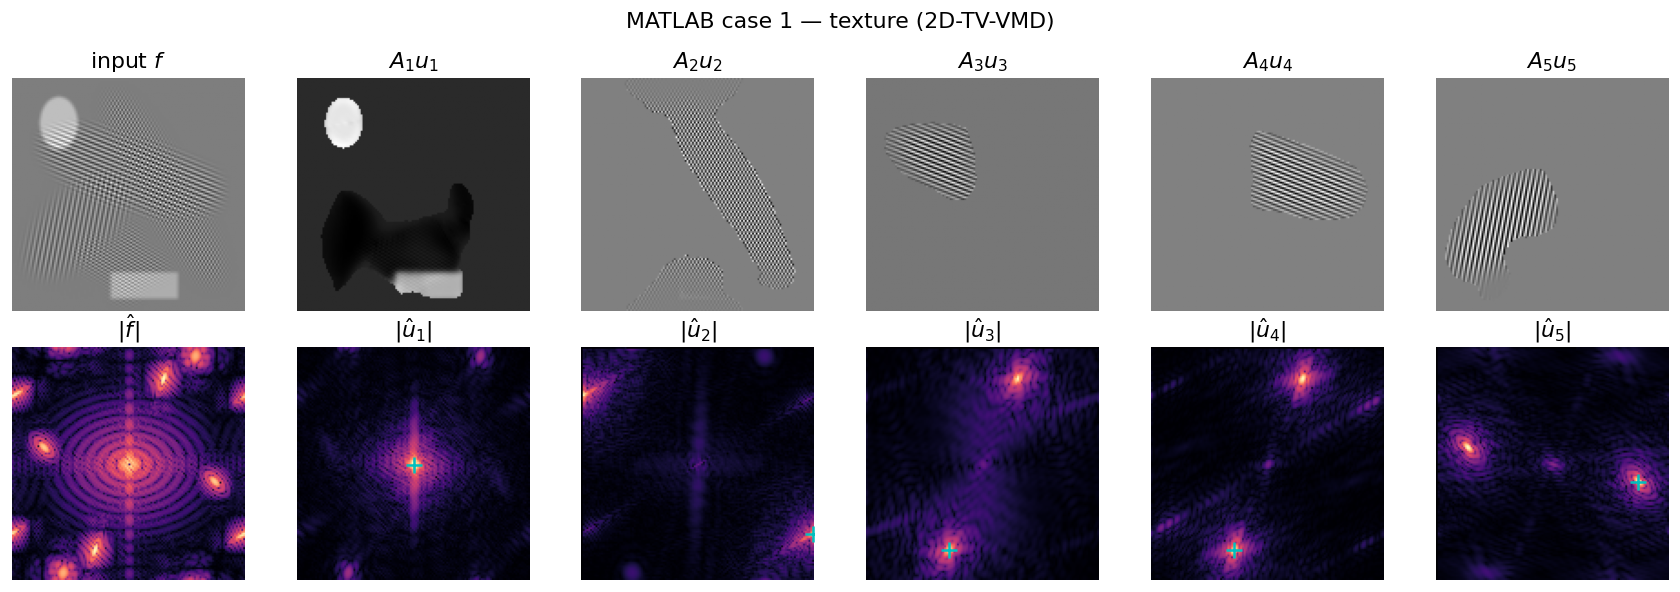

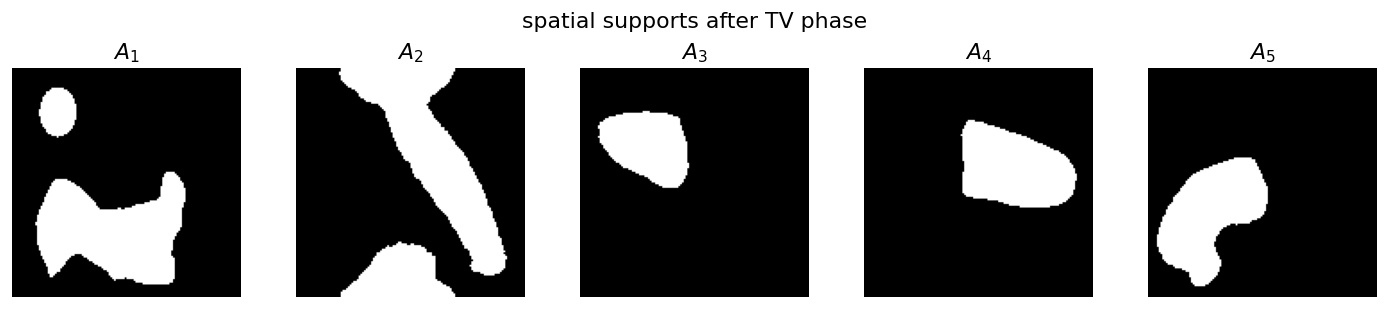

In [3]:
FAST = True  # set False for a closer match to MATLAB case 1 (slower)

signal = test_grayscale().astype(float)
signal = signal - signal.mean()

# Official MATLAB texture shipped at examples/texture.mat (repo root / examples)
mat_path = ROOT / "examples" / "texture.mat"
if not mat_path.exists():
    cwd = Path.cwd().resolve()
    mat_path = next(
        (
            cand
            for base in [cwd, *cwd.parents]
            for cand in (base / "texture.mat", base / "examples" / "texture.mat")
            if cand.is_file()
        ),
        mat_path,
    )
try:
    from scipy.io import loadmat

    if mat_path.exists():
        signal = np.asarray(loadmat(mat_path)["f"], dtype=float)
        signal = signal - signal.mean()
        print(f"loaded {mat_path}")
    else:
        print(f"texture.mat not found at {mat_path}; using test_grayscale()")
except Exception as exc:
    print("using test_grayscale(); SciPy/mat load skipped:", exc)

if FAST:
    signal = signal[::2, ::2]
    max_iter = 70
    A_phase = np.array([40.0, np.inf])
else:
    max_iter = 130
    A_phase = np.array([100.0, np.inf])

decomp = CVMD2D(
    K=5,
    alpha=1000,
    beta=0.5,
    gamma=500,
    delta=np.inf,
    rho=10,
    rho_k=10,
    tau=2.5,
    tau_k=2.5,
    t=1.5,
    DC=True,
    init="radially",  # MATLAB init = 0
    max_iter=max_iter,
    M=1,
    A_phase=A_phase,
)

u, v, omega, A, X = decomp.fit_transform(signal, return_all=True)
print("u shape:", u.shape, "  omega (2,K,M):", omega.shape)
print("centre frequencies ω (fx, fy) per mode:\n", omega[:, :, 0].T)

show_modes(signal, u, A=A, omega=omega, title="MATLAB case 1 — texture (2D-TV-VMD)")
show_supports(A, title="spatial supports after TV phase")


## 5. MATLAB case 4 — two crystal regions with $M=2$ submodes

Synthetic image from `VMD_2D_TV_test.m` **case 4**: two half-plane supports, each
carrying a pair of oriented cosines (shared support, two spectral submodes).
Here `A_phase=[100,150]` so the run ends in the **segmentation** (winner-takes-all) phase.


sum_k A_k ≈ 1 ? True


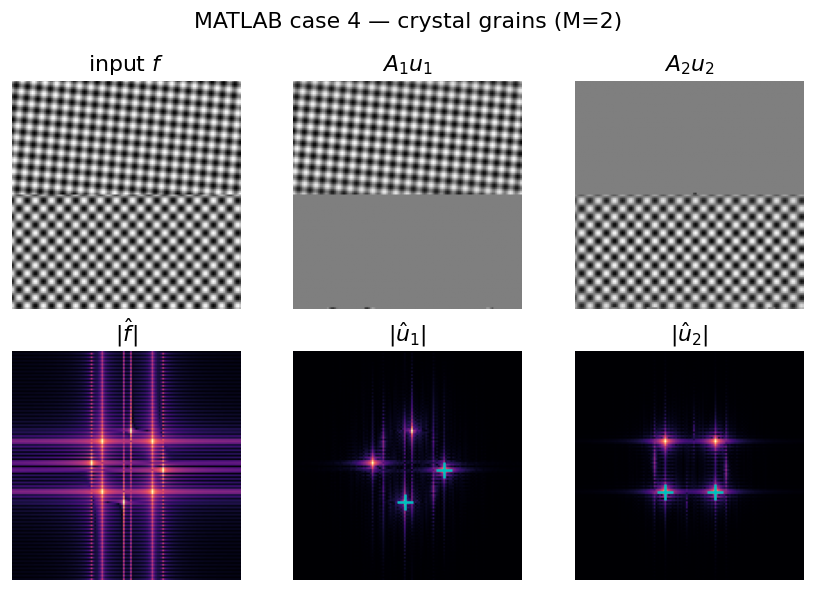

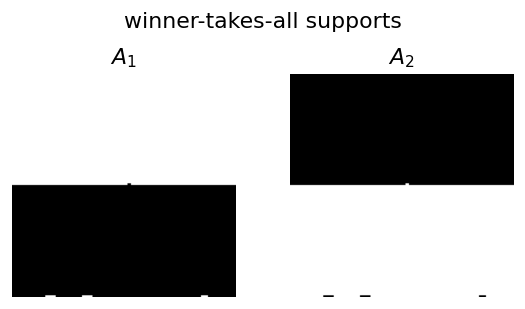

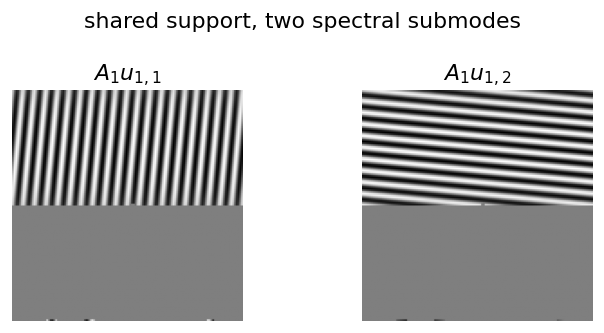

In [4]:
def matlab_case4(H=128):
    """Port of VMD_2D_TV_test.m case 4 (downscaled by default)."""
    f1 = 40.0 * (H / 256.0)  # keep similar cycles across the domain
    X, Y = np.meshgrid(np.arange(1, H + 1) / H, np.arange(1, H + 1) / H)
    M1 = np.zeros((H, H))
    M2 = np.zeros((H, H))
    M1[: H // 2, :] = 1.0
    M2[H // 2 :, :] = 1.0
    A_, B_ = 0.1, 1.0
    v1 = (
        np.cos(2 * np.pi * f1 / np.sqrt(1 + A_**2) * (X + A_ * Y))
        + np.cos(2 * np.pi * f1 / np.sqrt(1 + A_**2) * (A_ * X - Y))
    ) * M1
    v2 = (
        np.cos(2 * np.pi * f1 / np.sqrt(1 + B_**2) * (X + B_ * Y))
        + np.cos(2 * np.pi * f1 / np.sqrt(1 + B_**2) * (B_ * X - Y))
    ) * M2
    f = v1 + v2
    return f - f.mean()


crystal = matlab_case4(H=128 if FAST else 256)

decomp4 = CVMD2D(
    K=2,
    alpha=2000,
    beta=1.0,
    gamma=250,
    delta=np.inf,
    rho=7,
    rho_k=10,
    tau=0.0,
    tau_k=0.0,
    t=2.5,
    DC=False,
    init="radially",
    max_iter=80 if FAST else 200,
    M=2,
    A_phase=np.array([40.0, 55.0]) if FAST else np.array([100.0, 150.0]),
    u_tol=1e-8,
    A_tol=2e-4,
    omega_tol=1e-8,
)

u4, v4, omega4, A4, X4 = decomp4.fit_transform(crystal, return_all=True)
print("sum_k A_k ≈ 1 ?", np.allclose(A4.sum(axis=2), 1.0))

show_modes(
    crystal, u4, A=A4, omega=omega4, title="MATLAB case 4 — crystal grains (M=2)"
)
show_supports(A4, title="winner-takes-all supports")

# Show individual submodes for mode 1
fig, axes = plt.subplots(1, 2, figsize=(6, 2.8))
for m in range(2):
    axes[m].imshow(A4[:, :, 0] * u4[:, :, 0, m], cmap="gray")
    axes[m].set_title(f"$A_1 u_{{1,{m+1}}}$")
    axes[m].axis("off")
fig.suptitle("shared support, two spectral submodes")
fig.tight_layout()
plt.show()

## 6. MATLAB case 8 — overlapping chirp textures

Three spatially overlapping quadratic-phase (chirp) patterns. With
`A_phase=[100, Inf]` the algorithm stops in the **TV** phase (supports may overlap),
which is the right model when regions are not a hard partition.


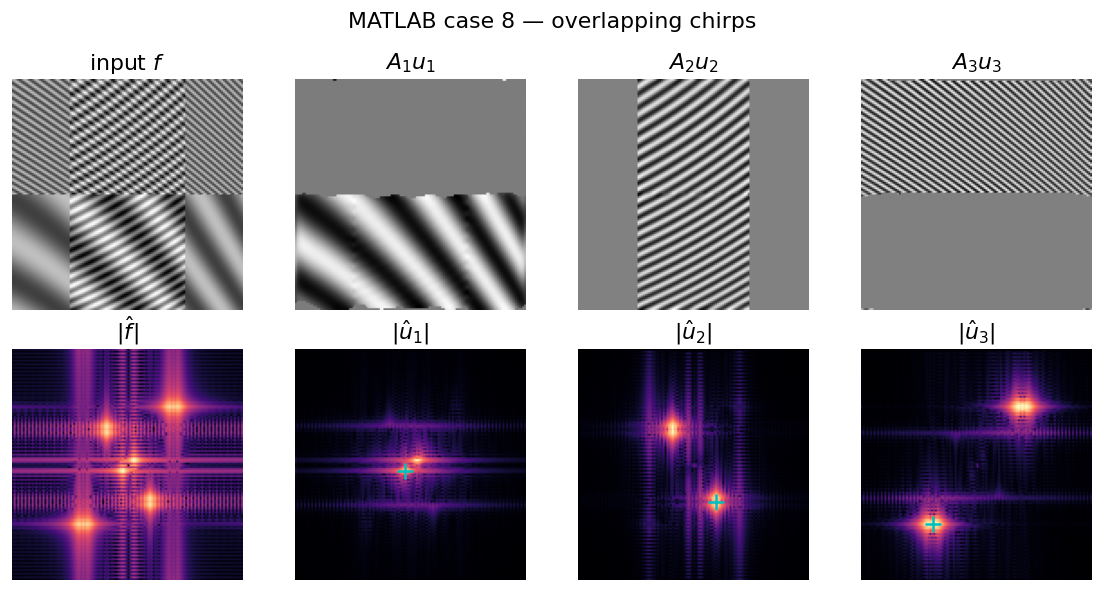

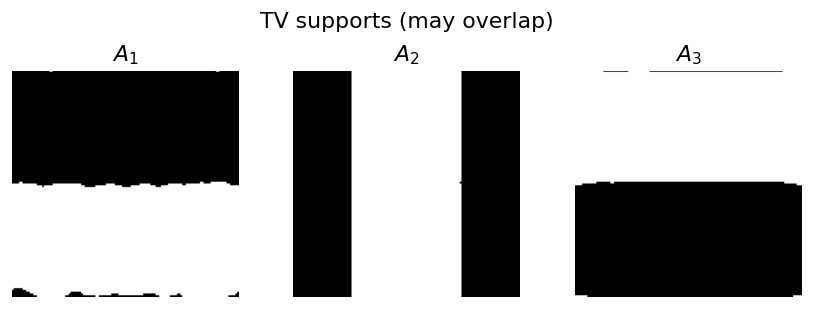

In [5]:
def matlab_case8(H=128):
    X, Y = np.meshgrid(np.arange(1, H + 1) / H, np.arange(1, H + 1) / H)
    # scale chirp rates roughly with resolution
    s = H / 256.0
    F1 = np.cos(10 * s * 2 * np.pi * ((X + 2) ** 2 - (Y + 3) ** 2))
    F2 = np.cos(5 * s * 2 * np.pi * (2 / 3 * (X + 0.5) ** 2 - 1 / 3 * (Y + 1) ** 2))
    F3 = np.cos(8 * s * 2 * np.pi * ((X + 1) ** 2 + (Y + 2) ** 2))
    M1 = np.zeros((H, H))
    M1[: H // 2, :] = 1.0
    M2 = np.zeros((H, H))
    M2[H // 2 :, :] = 1.0
    M3 = np.zeros((H, H))
    M3[:, H // 4 : 3 * H // 4] = 1.0
    f = F1 * M1 + F2 * M2 + F3 * M3
    return f - f.mean()


chirps = matlab_case8(H=128 if FAST else 256)

decomp8 = CVMD2D(
    K=3,
    alpha=2000,
    beta=1.0,
    gamma=1000,
    delta=np.inf,
    rho=7,
    rho_k=10,
    tau=1.0,
    tau_k=1.0,
    t=1.0,
    DC=False,
    init="radially",
    max_iter=80 if FAST else 200,
    M=1,
    A_phase=np.array([40.0, np.inf]) if FAST else np.array([100.0, np.inf]),
)

u8, v8, omega8, A8, X8 = decomp8.fit_transform(chirps, return_all=True)
show_modes(chirps, u8, A=A8, omega=omega8, title="MATLAB case 8 — overlapping chirps")
show_supports(A8, title="TV supports (may overlap)")

## 7. Parameter cheat-sheet (MATLAB ↔ PySDKit)

| MATLAB (`VMD_2D_TV`) | `CVMD2D` | Role |
|---|---|---|
| `alpha` | `alpha` | spectral bandwidth / Wiener weight |
| `beta` | `beta` | $L^1$ area of $A_k$ |
| `gamma` | `gamma` | heat / TV (MBO) strength |
| `delta` | `delta` | artifact threshold (`inf` → off) |
| `rho`, `rho_k` | `rho`, `rho_k` | data fidelity / $u$–$v$ splitting |
| `tau`, `tau_k` | `tau`, `tau_k` | dual steps (`tau=0` → noise slack) |
| `t` | `t` | ODE/PDE step for $A_k$ |
| `K`, `M` | `K`, `M` | modes / submodes |
| `DC` | `DC` | pin mode 1 at $(0,0)$ |
| `init=0/1` | `"radially"` / `"random"` | $\omega$ initialisation |
| `N` | `max_iter` | ADMM iterations |
| `A_phase=[a,b]` | `A_phase` | VMD → TV → Seg schedule |

Returns: `u` with shape `(Hy, Hx, K, M)`; with `return_all=True` also
`v`, `omega` `(2,K,M)`, `A` `(Hy,Hx,K)`, and artifact map `X`.

```python
from pysdkit import CVMD2D
u = CVMD2D(K=5, alpha=1000, DC=True)(image)
```
